#### Libraries

In [2]:
from pathlib import Path
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
from Levenshtein import ratio

#### Contants

In [3]:
FASTA_PATH = Path("../data/external/antibacterial.fasta")

CANONICAL_AMINO_ACIDS = set("ACDEFGHIKLMNPQRSTVWY")
AMINO_ACID_ORDER = list(CANONICAL_AMINO_ACIDS)

#### Data loading

In [4]:
def read_fasta(path: Path) -> pd.DataFrame:
    records = []
    header, sequence_parts = None, []

    def add_record():
        if header is None:
            return

        metadata = dict(
            token.split("=", 1)
            for token in header.split()[1:]
            if "=" in token
        )

        records.append(
            {
                "record_id": header.split()[0],
                "charge": float(metadata["charge"]),
                "disulfide": int(metadata["disulfide"]),
                "source_databases": metadata["dbs"].split("|"),
                "activity_tags": metadata["activity"].split("|"),
                "header": header,
                "sequence": "".join(sequence_parts).upper(),
                "sequence_length": len("".join(sequence_parts)),
            }
        )

    for raw_line in path.read_text().splitlines():
        line = raw_line.strip()

        if not line:
            continue

        if line.startswith(">"):
            add_record()
            header, sequence_parts = line[1:], []
        else:
            sequence_parts.append(line)

    add_record()

    return pd.DataFrame(records)


df = read_fasta(FASTA_PATH)
df.head()

,record_id,charge,disulfide,source_databases,activity_tags,header,sequence,sequence_length
0,MLAMP0003076,4.73,0,"[AMPDB, APD, BaAMPs, CAMP, CancerPPD, DBAASP, ...","[anti-biofilm, antibacterial, antimicrobial, a...",MLAMP0003076 len=15 charge=4.73 disulfide=0 db...,VNWKKILGKIIKVVK,15
1,MLAMP0000439,0.76,0,"[AMPDB, APD, BaAMPs, CAMP, CancerPPD, DBAASP, ...","[antimicrobial, anticancer, anti-biofilm]",MLAMP0000439 len=16 charge=0.76 disulfide=0 db...,GLFDVIKKVASVIGGL,16
2,MLAMP0000080,2.85,0,"[AMPDB, APD, BaAMPs, CAMP, CancerPPD, DBAASP, ...","[antimicrobial, antiparasitic, anticancer, ant...",MLAMP0000080 len=23 charge=2.85 disulfide=0 db...,GIGKFLHSAKKFGKAFVGEIMNS,23
3,MLAMP0000858,4.76,0,"[APD, BaAMPs, CAMP, CancerPPD, DBAASP, DRAMP, ...","[anti-biofilm, antibacterial, antimicrobial, a...",MLAMP0000858 len=26 charge=4.76 disulfide=0 db...,GIGAVLKVLTTGLPALISWIKRKRQQ,26
4,MLAMP0004306,2.76,0,"[AMPDB, APD, CAMP, DBAASP, DRAMP, InverPep, Pa...","[anti-gram+, antibacterial, antimicrobial, ant...",MLAMP0004306 len=10 charge=2.76 disulfide=0 db...,GLLKRIKTLL,10


#### Check for duplicates 

In [6]:
print(f"Number of duplicated sequences: {df.duplicated(subset="sequence").sum()}")

Number of duplicated sequences: 0


#### Length distribution analysis

Minimum length: 8
Maximum length: 50
Median length: 18
Mean length: 18.7


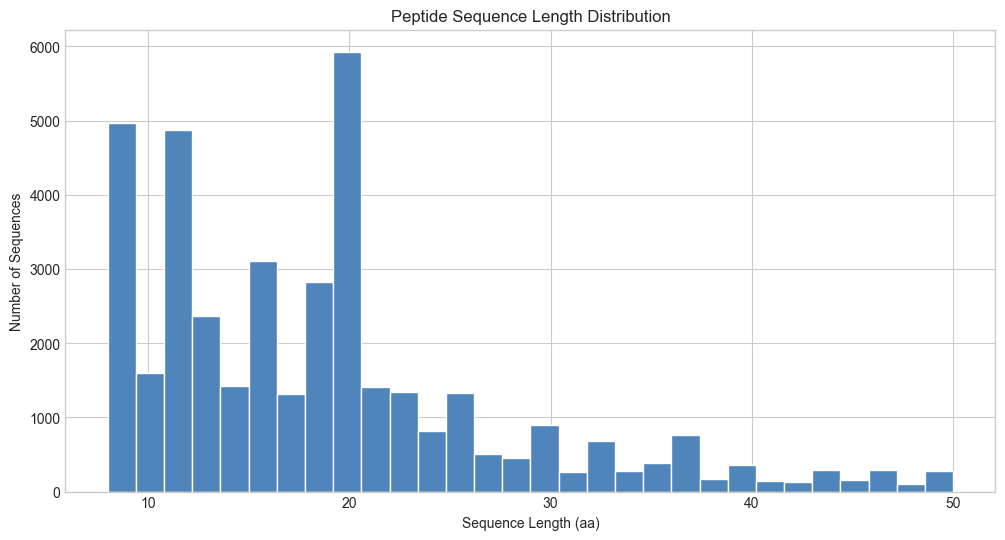

In [31]:
min_length = df["sequence_length"].min()
max_length = df["sequence_length"].max()
median_length = df["sequence_length"].median()
mean_length = df["sequence_length"].mean()

print(f"Minimum length: {min_length}")
print(f"Maximum length: {max_length}")
print(f"Median length: {median_length:.0f}")
print(f"Mean length: {mean_length:.1f}")


plt.figure(figsize=(12, 6))
plt.hist(
    df["sequence_length"],
    bins=30,
    color="#4f85ba",
    edgecolor="white",
)

plt.title("Peptide Sequence Length Distribution")
plt.xlabel("Sequence Length (aa)")
plt.ylabel("Number of Sequences")
plt.show()

#### Analysis of amino acid composition

Sequences containing only canonical amino acids: 39,448
Sequences containing non-canonical residues: 0


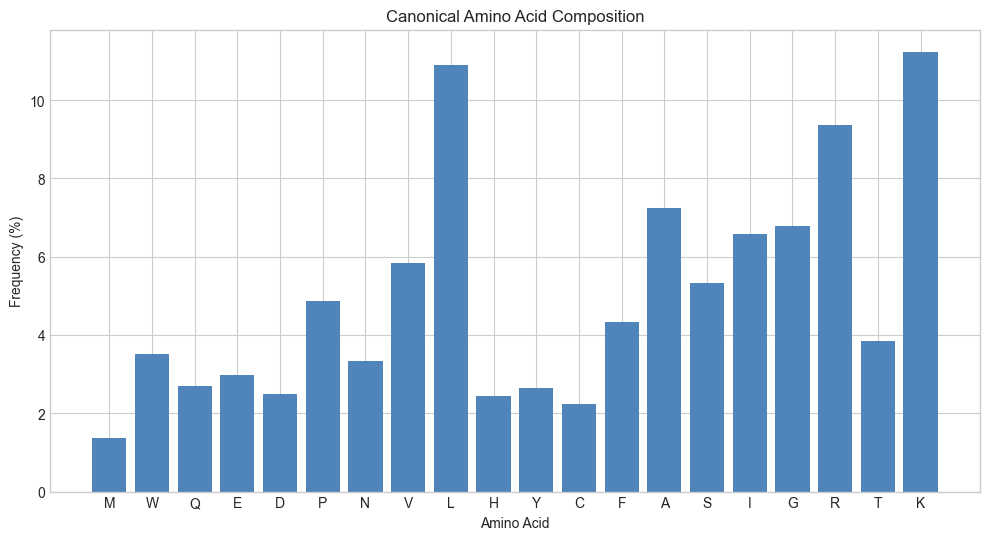

In [30]:
df["invalid_residues"] = df["sequence"].apply(
    lambda sequence: "".join(sorted(set(sequence) - CANONICAL_AMINO_ACIDS))
)
df["is_canonical"] = df["invalid_residues"].eq("")

n_canonical = df["is_canonical"].sum()
n_noncanonical = (~df["is_canonical"]).sum()

print(f"Sequences containing only canonical amino acids: {n_canonical:,}")
print(f"Sequences containing non-canonical residues: {n_noncanonical:,}")

if n_noncanonical > 0:
    display(
        df.loc[
            ~df["is_canonical"],
            ["record_id", "sequence", "invalid_residues"],
        ].head(10)
    )

all_residues = "".join(df["sequence"])
amino_acid_counts = Counter(all_residues)
total_residues = len(all_residues)

composition = pd.DataFrame(
    {
        "amino_acid": AMINO_ACID_ORDER,
        "count": [amino_acid_counts[aa] for aa in AMINO_ACID_ORDER],
    }
)
composition["frequency_percent"] = (
    100 * composition["count"] / total_residues
)


plt.figure(figsize=(12, 6))
plt.bar(
    composition["amino_acid"],
    composition["frequency_percent"],
    color="#4f85ba",
)

plt.title("Canonical Amino Acid Composition")
plt.xlabel("Amino Acid")
plt.ylabel("Frequency (%)")
plt.show()

#### Headers analysis

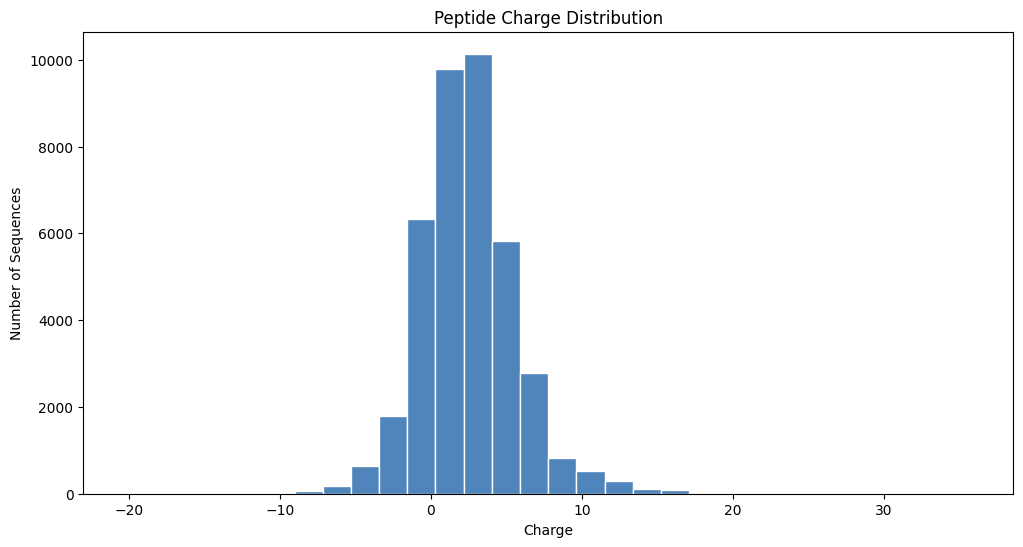

In [7]:
plt.figure(figsize=(12, 6))

plt.hist(
    df["charge"],
    bins=30,
    color="#4f85ba",
    edgecolor="white",
)

plt.title("Peptide Charge Distribution")
plt.xlabel("Charge")
plt.ylabel("Number of Sequences")
plt.show()

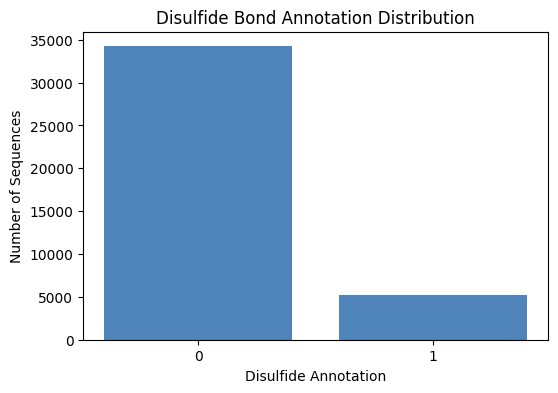

In [17]:
disulfide_counts = df["disulfide"].value_counts().sort_index()

plt.figure(figsize=(6, 4))

plt.bar(
    disulfide_counts.index.astype(str),
    disulfide_counts.values,
    color="#4f85ba",
)

plt.title("Disulfide Bond Annotation Distribution")
plt.xlabel("Disulfide Annotation")
plt.ylabel("Number of Sequences")
plt.show()

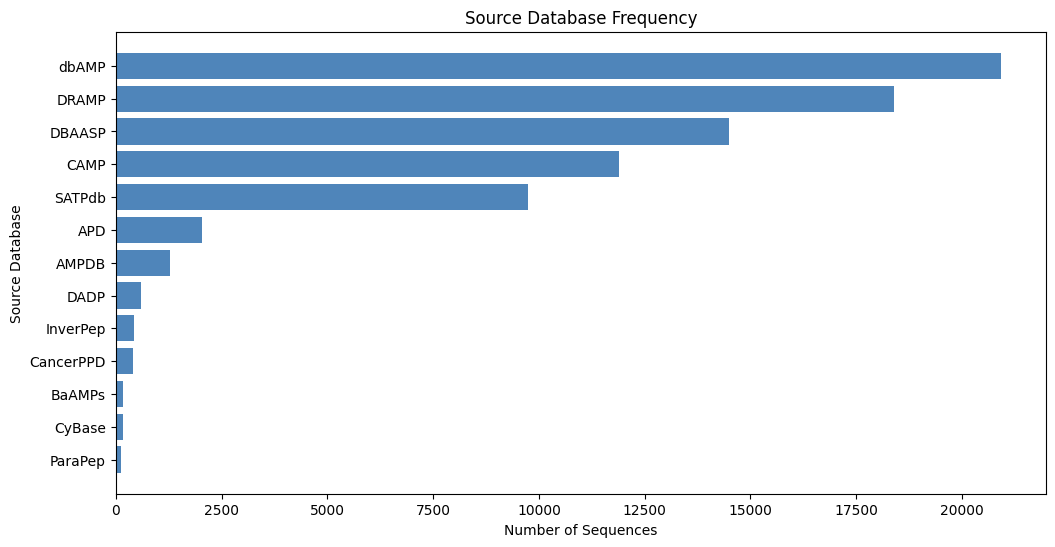

In [9]:
database_counts = (
    df.explode("source_databases")["source_databases"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(12, 6))

plt.barh(
    database_counts.index,
    database_counts.values,
    color="#4f85ba",
)

plt.title("Source Database Frequency")
plt.xlabel("Number of Sequences")
plt.ylabel("Source Database")
plt.show()

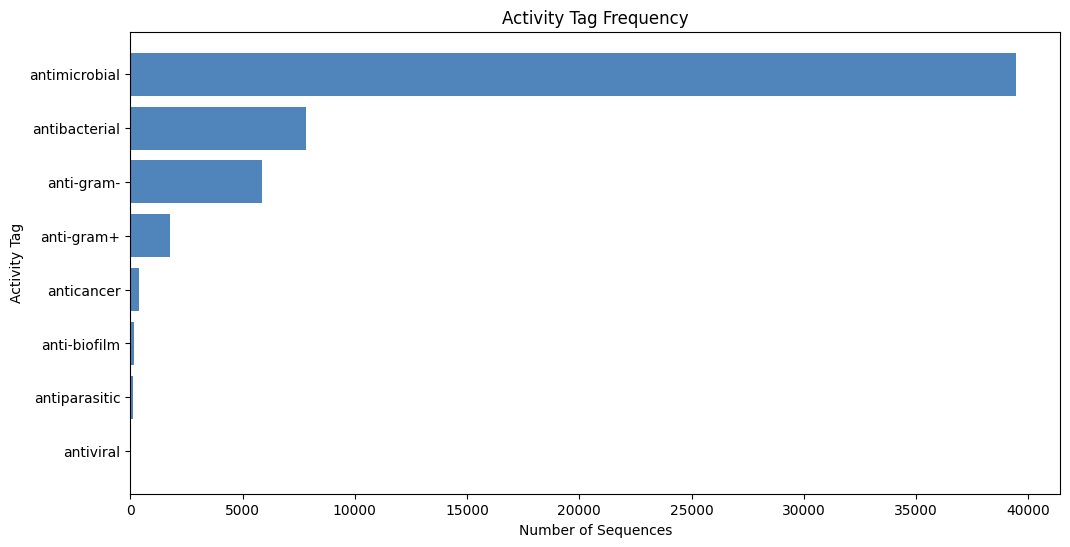

In [10]:
activity_counts = (
    df.explode("activity_tags")["activity_tags"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(12, 6))

plt.barh(
    activity_counts.index,
    activity_counts.values,
    color="#4f85ba",
)

plt.title("Activity Tag Frequency")
plt.xlabel("Number of Sequences")
plt.ylabel("Activity Tag")
plt.show()

#### Assessment of the similarity of a random sample of sequences

In [ ]:
unique_sequences = df["sequence"].to_numpy()
n_sequences = len(unique_sequences)

max_pairs = n_sequences * (n_sequences - 1) // 2
n_pairs = min(100000, max_pairs)

rng = np.random.default_rng(42)
sampled_pairs = set()

while len(sampled_pairs) < n_pairs:
    first_index, second_index = rng.choice(
        n_sequences,
        size=2,
        replace=False,
    )
    sampled_pairs.add(tuple(sorted((first_index, second_index))))

similarities = np.array(
    [
        ratio(
            unique_sequences[first_index],
            unique_sequences[second_index],
        )
        for first_index, second_index in sampled_pairs
    ]
)

print(f"Sampled sequence pairs: {len(similarities):,}")
print(f"Mean similarity: {similarities.mean():.3f}")
print(f"Median similarity: {np.median(similarities):.3f}")
print(f"Pairs with similarity > 0.60: {(similarities > 0.60).mean():.2%}")
print(f"Pairs with similarity > 0.80: {(similarities > 0.80).mean():.2%}")

Unique sequences: 39,448
Sampled sequence pairs: 100,000
Mean similarity: 0.250
Median similarity: 0.250
Pairs with similarity > 0.60: 0.20%
Pairs with similarity > 0.80: 0.06%


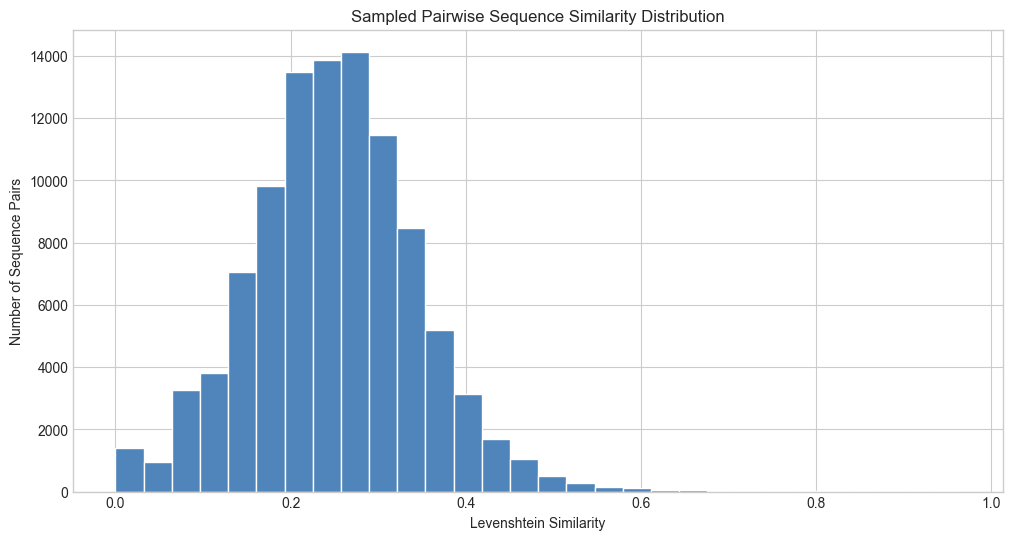

In [41]:
plt.figure(figsize=(12, 6))

plt.hist(
    similarities,
    bins=30,
    color="#4f85ba",
    edgecolor="white",
)

plt.title("Sampled Pairwise Sequence Similarity Distribution")
plt.xlabel("Levenshtein Similarity")
plt.ylabel("Number of Sequence Pairs")
plt.show()